# What is a channel?

*An introduction to photonic hardware and how to simulate it with optyx.*

A photonic quantum computer is built from a handful of components: sources
that emit single photons, chips of beam splitters and phase shifters that
interfere them, and detectors that count them. Around these sit the effects
that make hardware hard: photons get lost, photons that should be identical
are not quite, and the fast electronics that react to detection events feed
their decisions back into the optics — sometimes through a fibre loop, into
the next round of the experiment.

`optyx` describes every one of these components with a single data
structure: a **channel**. Wires are types — the quantum mode `qmode`, its
classical counterpart `mode` carrying photon counts, plus `qubit` and
`bit` — and boxes are completely positive maps between them. Boxes compose
in sequence with `>>` and in parallel with `@`, and the resulting diagram
is simulated by contracting a tensor network with `.eval()`.

This notebook builds up the picture one component at a time:

1. **gates** — beam splitters, phase shifters, interferometers;
2. **states** — Fock states and dual-rail qubits;
3. **effects** — postselection and observables;
4. **noise** — photon loss as a discarded environment;
5. **distinguishability** — photons with internal states;
6. **measurement** — classical wires and today's experiments;
7. **classical control** — feedforward;
8. **feedback** — loops, their streams and their fixed points;
9. **the universal setup** — all of the above in one diagram.

In [1]:
import numpy as np
from discopy.symmetric import Equation
from optyx import classical, photonic, qubits
from optyx.channel import Diagram, Discard, Measure, Ty, bit, mode, qmode

import warnings

warnings.filterwarnings("ignore", message="Trial error")  # cotengra probes

## 1. Gates

A photon travelling in a waveguide is a wire of type `qmode`. Photons do
not interact with each other directly; everything linear optics can do is
generated by two one- and two-mode gates, the **phase shifter** and the
**beam splitter**:

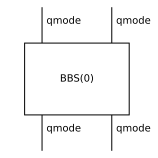

In [2]:
photonic.BS.draw(figsize=(2, 2))

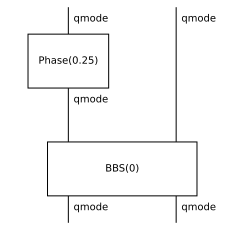

In [3]:
circuit = photonic.Phase(0.25) @ qmode >> photonic.BS
circuit.draw(figsize=(3, 3))

A linear optical gate is determined by its action on a single photon: a
unitary matrix sending input modes to output modes. `to_path()` recovers
it:

In [4]:
photonic.BS.to_path().array

array([[0.        +0.70710678j, 0.70710678+0.j        ],
       [0.70710678+0.j        , 0.        +0.70710678j]])

Composing beam splitters and phases gives **interferometers**. The
Mach-Zehnder interferometer `MZI(theta, phi)` is the building block of
programmable photonic chips, and `ansatz` tiles it into a universal
interferometer, here with symbolic parameters:

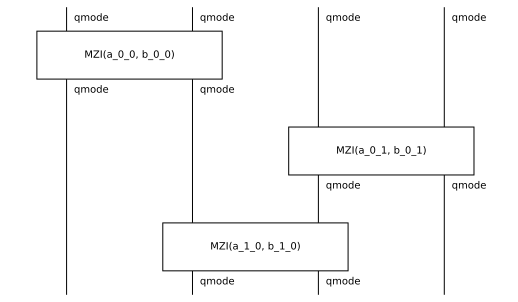

In [5]:
photonic.ansatz(4, 2).draw(figsize=(7, 4))

Conversely, any unitary matrix can be turned into a gate directly — here
the 3-mode Fourier interferometer:

In [6]:
fourier_matrix = np.array(
    [[np.exp(2j * np.pi * j * k / 3) for k in range(3)] for j in range(3)]
) / np.sqrt(3)
fourier = photonic.Gate(fourier_matrix, 3, 3, "Fourier")
assert np.allclose(fourier.to_path().array, fourier_matrix)
assert np.allclose(
    (fourier >> fourier.dagger()).to_path().array, np.eye(3))

## 2. States

Sources prepare **Fock states**: `Create(n_1, ..., n_k)` puts `n_i`
photons in the `i`-th mode. Feeding one photon into each arm of a beam
splitter gives the Hong-Ou-Mandel experiment:

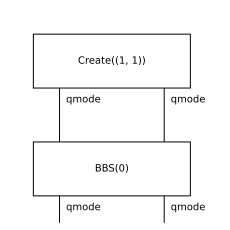

In [7]:
hom = photonic.Create(1, 1) >> photonic.BS
hom.draw(figsize=(3, 3))

In [8]:
{occupation: np.round(amplitude, 3)
 for occupation, amplitude in hom.eval().amplitudes().items()}

{(0, 2): 0.707j, (1, 1): (-0+0j), (2, 0): 0.707j}

The coincidence outcome $(1, 1)$ has amplitude zero: indistinguishable
photons bunch, and leave through the same port. This interference is the
resource behind linear optical quantum computing.

A **dual-rail qubit** is one photon shared between two modes:
$|0\rangle \mapsto |01\rangle$ and $|1\rangle \mapsto |10\rangle$.
`DualRail` encodes qubit states into photonics:

In [9]:
plus = qubits.Ket("+") >> photonic.DualRail(1)
plus.eval().amplitudes()

{(0, 1): (0.7071067811865476+0j), (1, 0): (0.7071067811865476+0j)}

Whole qubit circuits transport to photonics the same way: `to_dual_rail`
maps a ZX diagram — here a GHZ state — to the linear optical circuit that
postselects it:

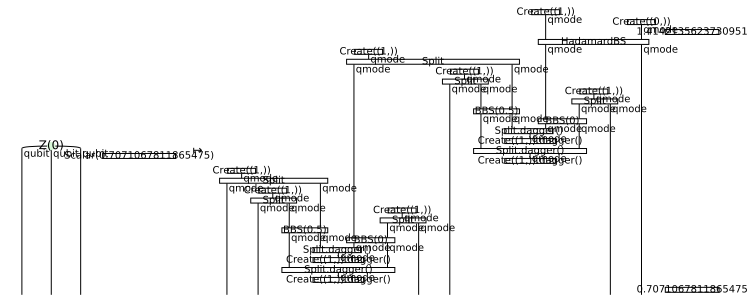

In [10]:
ghz = qubits.Z(0, 3) @ qubits.Scalar(1 / np.sqrt(2))
ghz_dr = ghz.to_dual_rail()
Equation(ghz, ghz_dr, symbol="$\\mapsto$").draw(figsize=(10, 4))

In [11]:
{occupation: round(abs(amplitude), 3)
 for occupation, amplitude in ghz_dr.eval().amplitudes().items()
 if abs(amplitude) > 1e-12}

{(0, 1, 0, 1, 0, 1): 0.707, (1, 0, 1, 0, 1, 0): 0.707}

## 3. Effects

Effects are states flipped upside down: where `Create(n)` prepares an
occupation number, `Select(n)` postselects on detecting it. Closing a
circuit with a state at the top and an effect at the bottom leaves a
scalar — the amplitude
$\langle 2, 0 \,|\, \mathtt{BS} \,|\, 1, 1\rangle = i/\sqrt{2}$:

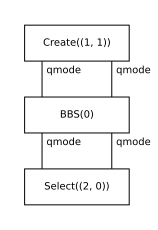

In [12]:
amplitude = photonic.Create(1, 1) >> photonic.BS >> photonic.Select(2, 0)
amplitude.draw(figsize=(2, 3))

In [13]:
amplitude.eval().tensor.array

array(0.+0.70710678j)

**Observables** are built from creation and annihilation operators.
`Diagram.from_bosonic_operator` takes a list of `(mode, dagger)` pairs
applied in diagram order, so the photon-number operator
$a^\dagger a$ on one mode is:

In [14]:
number = Diagram.from_bosonic_operator(
    n_modes=1, operators=((0, False), (0, True)))
state = photonic.Create(2)
(state >> number >> state.dagger()).eval().tensor.array

array(2.+0.j)

Sandwiching the operator between a state and its dagger gives the
expectation value $\langle \psi | N | \psi \rangle = 2$. Operators add up
to formal sums, so the total photon number is an observable too — and an
interferometer conserves it:

In [15]:
total = Diagram.from_bosonic_operator(2, ((0, False), (0, True))) \
    + Diagram.from_bosonic_operator(2, ((1, False), (1, True)))
state = photonic.Create(2, 1)
rotated = state >> photonic.BS
assert np.allclose(
    (state >> total >> state.dagger()).eval().tensor.array,
    (rotated >> total >> rotated.dagger()).eval().tensor.array)
(state >> total >> state.dagger()).eval().tensor.array

array(3.+0.j)

## 4. Noise

Everything so far was **pure**: gates were unitary, states were vectors.
Real hardware is not, and this is where channels earn their name. The
leading imperfection in photonics is **photon loss**: absorption,
scattering, imperfect coupling, detector inefficiency.

Loss has a precise diagrammatic description: a beam splitter of
transmissivity $\eta$ whose second output — the **environment** — is
discarded. Noise is nothing but a unitary interaction with an environment
we do not observe; this is the Stinespring picture, and it is how every
`Channel` in optyx is defined: a Kraus map into `cod @ env`, with `env`
traced out.

The `double` method makes this concrete. It maps a channel to its action
on density matrices: the Kraus map beside its conjugate, with the
environment wire bent around and shared:

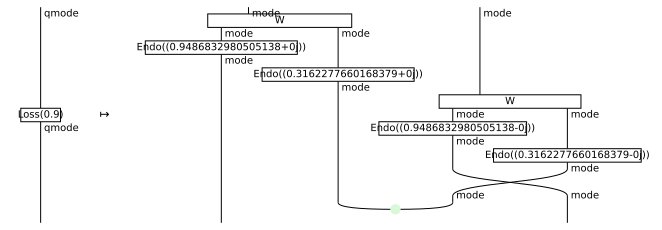

In [16]:
loss = photonic.PhotonLoss(0.9)
Equation(loss, loss.double(), symbol="$\\mapsto$").draw(figsize=(9, 3))

Once a diagram contains a discarded environment, `.eval()` returns
probabilities rather than amplitudes. With 20% loss on one arm, the
Hong-Ou-Mandel dip degrades — single-photon outcomes appear:

In [17]:
lossy_hom = (
    photonic.Create(1, 1)
    >> photonic.PhotonLoss(0.8) @ photonic.Id(1)
    >> photonic.BS
    >> photonic.NumberResolvingMeasurement(2))
lossy_hom.eval().prob_dist(round_digits=4)

{(0, 1): 0.1, (0, 2): 0.4, (1, 0): 0.1, (2, 0): 0.4}

## 5. Distinguishability

Photons carry internal degrees of freedom — arrival time, frequency,
polarisation. Two photons interfere only to the extent that their
internal states overlap, and a source is never perfect.

`Create` accepts an internal state per photon, and `inflate(d)` dilates
each mode into `d` copies, one per internal dimension, so the diagram can
tell the photons apart. Here the overlap is
$\langle s_1 | s_2 \rangle = 1/\sqrt{2}$:

In [18]:
s1 = np.array([1, 0])
s2 = np.array([1, 1]) / np.sqrt(2)
hom_partial = (
    photonic.Create(1, 1, internal_states=(s1, s2))
    >> photonic.BS
    >> photonic.NumberResolvingMeasurement(2))
hom_partial.inflate(2).eval().prob_dist(round_digits=4)

{(0, 2): 0.375, (1, 1): 0.25, (2, 0): 0.375}

The coincidence probability is
$\frac{1}{2}(1 - |\langle s_1 | s_2 \rangle|^2) = \frac{1}{4}$:
halfway between the vanishing dip of identical photons and the classical
$\frac{1}{2}$ of fully distinguishable ones. The depth of this dip is how
indistinguishability is measured in the lab.

## 6. Measurement

So far outcomes were read off by postselection, one amplitude at a time.
A detector does more: it turns a quantum mode into a **classical wire**
carrying the observed photon count. Classical types come with their
quantum counterparts — `Measure(qmode)` maps `qmode` to `mode`, and on
qubits `Measure(qubit)` maps to `bit`.

This gives the shape of most experiments running today, boson sampling:
a Fock state, an interferometer, number-resolving detectors on every
mode.

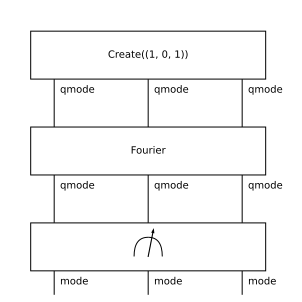

In [19]:
sampling = (
    photonic.Create(1, 0, 1)
    >> fourier
    >> photonic.NumberResolvingMeasurement(3))
sampling.draw(figsize=(4, 4))

In [20]:
sampling.eval().prob_dist(round_digits=4)

{(0, 0, 2): 0.2222,
 (0, 1, 1): 0.1111,
 (0, 2, 0): 0.2222,
 (1, 0, 1): 0.1111,
 (1, 1, 0): 0.1111,
 (2, 0, 0): 0.2222}

The output is the full distribution over detection patterns — note the
suppression of some outcomes and enhancement of others, pure multi-photon
interference at work.

## 7. Classical control

Classical wires can do more than end the experiment: their values can be
processed and **fed forward** to condition gates later in the circuit,
within the coherence time of the photons. This is how fusion-based and
measurement-based photonic schemes operate.

Two boxes suffice. `ClassicalFunction` lifts any Python function to a
channel between classical wires, and `BitControlledGate(gate, default)`
applies `gate` when its control bit is 1 and `default` otherwise. Here we
measure one output of a beam splitter and, when the count is odd, apply a
phase to the other:

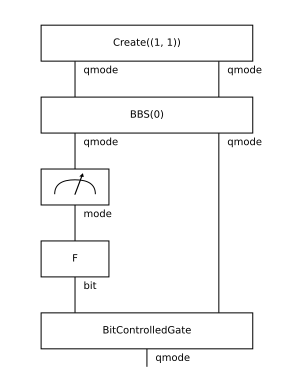

In [21]:
parity = classical.ClassicalFunction(lambda n: [n[0] % 2], mode, bit)
controlled_phase = classical.BitControlledGate(
    photonic.Phase(0.5), photonic.Id(1))
feedforward = (
    photonic.Create(1, 1)
    >> photonic.BS
    >> photonic.NumberResolvingMeasurement(1) @ qmode
    >> parity @ qmode
    >> controlled_phase)
feedforward.draw(figsize=(4, 5))

One gate measures, the other is controlled: the codomain is a quantum
mode whose state depends on a classical computation on a measurement
outcome — a genuinely classical-quantum channel.

## 8. Feedback

The last hardware ingredient is the **delay loop**: a fibre that stores
part of the output of a circuit and feeds it back as input to the next
repetition, one time step later. This is how time-bin architectures and
the recent feedback boson sampling experiments work.

`feedback` closes the last output of a diagram onto its last input,
with an initial `state` filling the loop at the first time step. A photon
enters at every tick and a Mach-Zehnder couples it to the loop:

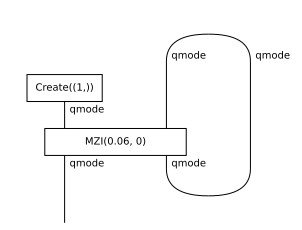

In [22]:
loop = (
    photonic.Create(1) @ qmode >> photonic.MZI(0.06, 0)
).feedback(mem=qmode, state=photonic.Create(0))
loop.draw(figsize=(4, 3))

The loop has **stream semantics**: `unroll(n)` lays out `n + 1` time
steps side by side, the memory wire threading each step to the next:

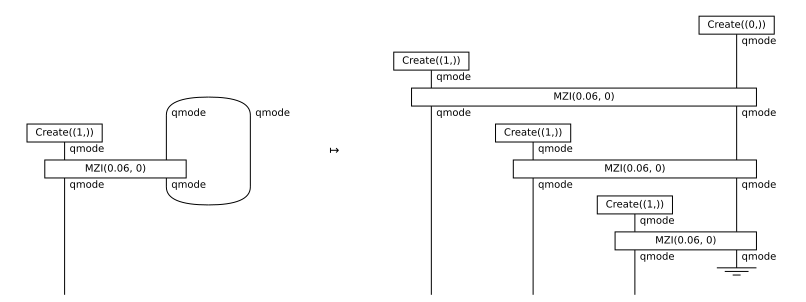

In [23]:
Equation(loop, loop.unroll(2), symbol="$\\mapsto$").draw(figsize=(11, 4))

`at_time(t)` runs the loop for `t` steps and keeps the last output.
Watch the photon count at the output settle as the loop fills up:

In [24]:
measured = loop >> photonic.NumberResolvingMeasurement(1)
for t in (0, 2, 8):
    distribution = measured.at_time(t).eval().prob_dist(round_digits=4)
    print(t, {count: p for count, p in distribution.items() if p})

0 {(0,): 0.9649, (1,): 0.0351}
2 {(0,): 0.1233, (1,): 0.761, (2,): 0.1093, (3,): 0.0064}


8 {(0,): 0.1241, (1,): 0.7587, (2,): 0.1105, (3,): 0.0067}


The distribution it settles into is the **fixed point** of the loop:
the stationary state of the channel that one time step induces on the
memory. `eigen_fix` computes it directly, by diagonalising that transfer
channel instead of iterating it — and for lossy loops, `fix` approximates
it by contracting an unrolling of certified depth:

In [25]:
{count: p for count, p in
 measured.eigen_fix(chi=8).prob_dist(round_digits=4).items() if p}

{(0,): 0.1241, (1,): 0.7587, (2,): 0.1105, (3,): 0.0067}

## 9. The universal setup

Every component is now on the table, and they compose into one picture.
A general discrete-time photonic experiment is:

- a state $\psi$ of $M$ fresh qmodes entering at every time step,
- a **classically controlled isometry** $U$ from $M + L$ qmodes to
  $M + L + E$ qmodes, controlled by $C$ classical wires,
- where $E$ is a **discarded environment** modelling the loss,
- and $L$ qmodes flow back through **feedback loops**,
- the $M$ output qmodes are measured with `Measure(qmode)`,
- a classical **feedforward** function maps the $M$ counts to $X + C$
  classical wires: $X$ outputs of the experiment, and $C$ controls fed
  back into $U$ at the next time step.

Gates, states, effects, noise, measurement, classical control and
feedback: one diagram, and that diagram is a channel from nothing to
`bit ** X` — the distribution of outcomes it produces each tick.

In [26]:
class UniversalSetup(Diagram):
    """
    A state `psi` on `qmode ** M` enters a classically controlled isometry
    at every time step, together with `L` feedback qmodes and `C` control
    bits; the isometry's environment is discarded, the `M` visible qmodes
    are measured, and a feedforward function computes `X` outcome bits and
    the next `C` controls.

    Parameters:
        psi : a state on `qmode ** M`, the fresh input of each time step.
        controlled : the controlled isometry `U`, a pure channel from
            `bit ** C @ qmode ** (M + L)` to `qmode ** (M + L)`.
        feedforward : a channel from `mode ** M` to `bit ** (X + C)`.
        survival : the probability a photon survives one pass; the
            environment `E` is the one `PhotonLoss` discards.
        memory : a state on `qmode ** L @ bit ** C` filling the loops at
            the first time step, vacuum and 0 by default.
    """
    def __new__(cls, psi, controlled, feedforward, M, L, X, C,
                survival=1, memory=None):
        mem = qmode ** L @ bit ** C
        if memory is None:
            memory = Diagram.id(Ty()).tensor(
                photonic.Create(*(L * (0,))),
                *(classical.Bit(0) for _ in range(C)))
        environment = Diagram.id(Ty()).tensor(
            *(photonic.PhotonLoss(survival) for _ in range(M + L)))
        step = (
            psi @ Diagram.id(mem)
            >> Diagram.permutation(
                [M + L + i for i in range(C)] + list(range(M + L)),
                qmode ** (M + L) @ bit ** C)
            >> controlled
            >> environment
            >> Measure(qmode ** M) @ Diagram.id(qmode ** L)
            >> feedforward @ Diagram.id(qmode ** L)
            >> Diagram.id(bit ** X) @ Diagram.swap(bit ** C, qmode ** L))
        return step.feedback(
            mem=mem, state=memory, effect=Diagram.id(Ty()).tensor(
                *(Discard(qmode) for _ in range(L)),
                *(Discard(bit) for _ in range(C))))

Here is an instance: a single-photon source fires into a lossy delay
loop. A detector watches the visible mode; the parity of its count is
the outcome bit of the experiment, and whether anything arrived at all
decides whether the next photon is coupled into the loop by a beam
splitter or passes straight through:

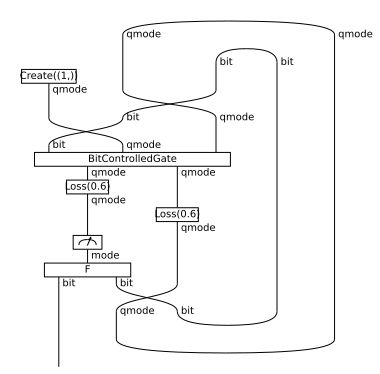

In [27]:
setup = UniversalSetup(
    psi=photonic.Create(1),
    controlled=classical.BitControlledGate(photonic.BS, photonic.Id(2)),
    feedforward=classical.ClassicalFunction(
        lambda n: [n[0] % 2, 1 if n[0] > 0 else 0], mode, bit ** 2),
    M=1, L=1, X=1, C=1, survival=0.6)
setup.draw(figsize=(5, 5))

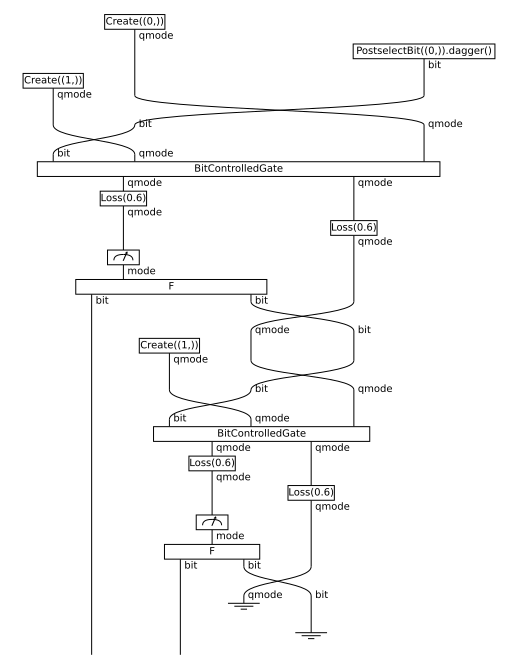

In [28]:
setup.unroll(1).draw(figsize=(7, 9))

The setup simulates like any other channel — its outcome distribution
converges over time:

In [29]:
for t in (0, 2, 5, 10):
    print(t, setup.at_time(t).eval().prob_dist(round_digits=4))

0 {(0,): 0.4, (1,): 0.6}


2 {(0,): 0.526, (1,): 0.474}


5 {(0,): 0.5443, (1,): 0.4557}


10 {(0,): 0.5448, (1,): 0.4552}


and both fixed-point methods agree on where it converges to:

In [30]:
print(setup.eigen_fix(tol=1e-6).prob_dist(round_digits=4))
print(setup.fix(tol=1e-3, loss=0.4, chi=None).prob_dist(round_digits=4))

{(0,): 0.5448, (1,): 0.4552}


{(0,): 0.5448, (1,): 0.4552}


So, what is a channel? It is the one interface behind every box in this
notebook: a Kraus map with a discarded environment, on quantum and
classical wires alike. Unitary gates are channels with no environment,
states are channels from nothing, effects and measurements are channels
into classical wires, loss is a channel with a one-mode environment,
feedforward is a channel between classical wires, and a feedback loop is
a channel with memory. The universal setup composes them all — and
whatever photonic experiment you have in mind, it is an instance.

To go further: see the
[stateful channels notebook](fixpoints.ipynb) for stream and fixed-point
semantics in depth, and the module documentation of
[`optyx.photonic`](../_api/optyx.photonic.html),
[`optyx.classical`](../_api/optyx.classical.html) and
[`optyx.qubits`](../_api/optyx.qubits.html) for the full library of
gates, states and measurements.